<a href="https://colab.research.google.com/github/anjicx/ComorbidityNetworkGNN/blob/main/GAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#imports
import pandas as pd
import numpy as np
import random
!pip install torch-geometric
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from torch_geometric.nn import SAGEConv, GATConv
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import roc_auc_score, average_precision_score
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.8 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
adj_matrices = {}
# made a dict 1:list of loaded matrix
for i in range(1, 9):
    path = f'/content/drive/MyDrive/Adj_Matrix_Age_ICD_Male/Adj_Matrix_Male_ICD_age_{i}.csv'
    adj_matrices[i] = pd.read_csv(path, sep=r"\s+", header=None, engine="python")
   # print(f"Age group {i}: shape {adj_matrices[i].shape}")
def normalize_matrix(df):
    for i in range(df.shape[0]):    # for each disease raw
        row_sum = df[i, :].sum()     # summ this disease with all
        if row_sum > 0:                  # skip diseases with no connections-for dividing with 0
            df[i, :] = df[i, :] / row_sum  # divide each value by the total
    return df
normalized_matrices={}
for i in range(1, 9):                          # for each age group 1-8
    raw = adj_matrices[i].values.copy()         # cpy
    norm = normalize_matrix(raw)  # NORMALIZATION
    normalized_matrices[i] = np.maximum(norm, norm.T) # SYMETRIC
    #MAX MEAN GNN WRITE

#ICD CODES
icd_df = pd.read_csv('/content/drive/MyDrive/AdjacencyMatrices/ICD10_Diagnoses_All.csv')
icd_codes = icd_df['icd_code'].tolist()
#print(f"{len(icd_codes)} codes, first 2: {icd_codes[:2]}")

#PREVALANCE ON AGE,YEAR

prev_df = pd.read_csv('/content/drive/MyDrive/AdjacencyMatrices/Prevalence_Sex_Age_Year_ICD.csv')
#print(prev_df.head())
#prev_df[prev_df['sex'] == 'Male'][['Age_Group', 'icd_code']].duplicated().sum()->its not unique
#PREVALANCE ON MEN

male_prev = (
    prev_df[prev_df['sex'] == 'Male']#FOR MALE
    .groupby(['Age_Group', 'icd_code'], as_index=False)['p']#GROUPED BY AGE GROUP,ICD COUNTING MEAN FOR P
    .mean()
)
#print(male_prev.head(5))

#PREVALENCE FEATURE VECTOR

age_labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79"]

prev_features = {} # age group-prevalance

for id, age in enumerate(age_labels, 1): #for each age group
    age_data = male_prev[male_prev['Age_Group'] == age].set_index('icd_code')['p'] # A00-0.003
    prev_vector = np.array([age_data.get(code, 0.0) for code in icd_codes])# 0.003
    prev_features[id] = prev_vector #prev[1]=[0.003,0.02] all prevel for age group 1, 2, ..
    print(f"Age group {id} ({age}): {(prev_vector > 0).sum()} diseases have prevalence")

Age group 1 (0-9): 883 diseases have prevalence
Age group 2 (10-19): 897 diseases have prevalence
Age group 3 (20-29): 929 diseases have prevalence
Age group 4 (30-39): 932 diseases have prevalence
Age group 5 (40-49): 953 diseases have prevalence
Age group 6 (50-59): 935 diseases have prevalence
Age group 7 (60-69): 925 diseases have prevalence
Age group 8 (70-79): 883 diseases have prevalence


In [3]:
#BLOCK MAP FOR DISEASE BLOCKS
block_map = {
    'A': 0, 'B': 0,          # infectious
    'C': 1, 'D': 1,          # neoplasms / blood
    'E': 2,                  # endocrine
    'F': 3,                  # mental
    'G': 4,                  # nervous
    'H': 5,                  # eye/ear
    'I': 6,                  # circulatory
    'J': 7,                  # respiratory
    'K': 8,                  # digestive
    'L': 9,                  # skin
    'M': 10,                 # musculoskeletal
    'N': 11,                 # genitourinary
    'O': 12,                 # pregnancy
    'P': 13,                 # perinatal
    'Q': 14,                 # congenital
    'R': 15,                 # symptoms
    'S': 16, 'T': 16,        # injury
    'V': 17, 'W': 17, 'X': 17, 'Y': 17,  # external causes
    'Z': 18                  # factors influencing health
}

num_blocks = max(block_map.values()) + 1
blocks = np.zeros((len(icd_codes), num_blocks))

for j, code in enumerate(icd_codes):
    first = code[0].upper()
    if first in block_map:
        blocks[j, block_map[first]] = 1

In [4]:
pyg_graphs_1feat  = {}
pyg_graphs_20feat = {}

node_mappings = {}

for i in range(1, 9):
    #MATRIX FOR EACH AGE GROUP
    mat = normalized_matrices[i]
    #KEEPING ONLY CONNECTED NODES
    degree = (mat > 0).sum(axis=1)
    connected_nodes = np.where(degree > 0)[0]
    node_mappings[i] = connected_nodes

    sub_mat = mat[np.ix_(connected_nodes, connected_nodes)]
    N = len(connected_nodes)

    rows, cols = np.where(
        (sub_mat > 0) & (np.triu(np.ones_like(sub_mat), k=1).astype(bool))
    )
    #EDGE INDEX=TELLING WHO THE NEIGHBOURS ARE//GRAPHS STRUCTURE
    edge_index = torch.tensor(np.vstack([
        np.concatenate([rows, cols]),
        np.concatenate([cols, rows])
    ]), dtype=torch.long)

#IF U CHOOSE LATER ON TO ADD EDGE WEIGHT PROBABL WILL BE DATA LEAKAGE THEN? BINARY 0/1 IS OK--u will need also to create it

    # node features
    prev_sub  = prev_features[i][connected_nodes]   # shape [N]
    block_sub = blocks[connected_nodes]             # shape [N, 19]
  #X = NODE FEATURE MAP//WHAT EACH NODE HAS AS FEATURES
    x1  = torch.tensor(prev_sub.reshape(-1, 1), dtype=torch.float)
    x20 = torch.tensor(
        np.hstack([prev_sub.reshape(-1, 1), block_sub]),
        dtype=torch.float
    )

    # SAVING X,INDEX FOR EACH GRAPH

    pyg_graphs_1feat[i]  = Data(x=x1,  edge_index=edge_index,
                                num_nodes=N)

    pyg_graphs_20feat[i] = Data(x=x20, edge_index=edge_index,
                                num_nodes=N)

    # print(f"Age {i}: kept {N}/1080 nodes, {len(rows)} undirected edges, x20 shape={x20.shape}")

In [5]:
import copy
import torch
import torch.nn.functional as F
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import roc_auc_score, average_precision_score

train_graphs = {}
val_graphs = {}
test_graphs = {}

for i in range(1, 9):
#TO COUNT IN EACH GROUP RATIO WHICH IS FOR NEGATIVE TO POSITIVE AND THAT TO APPLY
    transform = RandomLinkSplit(
        num_val=0.15,
        num_test=0.15,
        is_undirected=True,
        add_negative_train_samples=True,
        neg_sampling_ratio=10.0,
        split_labels=False
    )

    train_data, val_data, test_data = transform(pyg_graphs_20feat[i])

    train_graphs[i] = train_data
    val_graphs[i] = val_data
    test_graphs[i] = test_data

    # check class balance in each split
    for name, d in [("train", train_data), ("val", val_data), ("test", test_data)]:
        pos = int(d.edge_label.sum().item())
        neg = int(d.edge_label.numel() - pos)
        ratio = neg / pos if pos > 0 else float("inf")
        print(f"Age {i} | {name}: pos={pos}, neg={neg}, neg/pos={ratio:.2f}")

Age 1 | train: pos=299, neg=2990, neg/pos=10.00
Age 1 | val: pos=63, neg=630, neg/pos=10.00
Age 1 | test: pos=63, neg=630, neg/pos=10.00
Age 2 | train: pos=84, neg=840, neg/pos=10.00
Age 2 | val: pos=18, neg=180, neg/pos=10.00
Age 2 | test: pos=18, neg=180, neg/pos=10.00
Age 3 | train: pos=220, neg=2200, neg/pos=10.00
Age 3 | val: pos=46, neg=460, neg/pos=10.00
Age 3 | test: pos=46, neg=460, neg/pos=10.00
Age 4 | train: pos=443, neg=4430, neg/pos=10.00
Age 4 | val: pos=94, neg=940, neg/pos=10.00
Age 4 | test: pos=94, neg=940, neg/pos=10.00
Age 5 | train: pos=1043, neg=10430, neg/pos=10.00
Age 5 | val: pos=223, neg=2230, neg/pos=10.00
Age 5 | test: pos=223, neg=2230, neg/pos=10.00
Age 6 | train: pos=1720, neg=17200, neg/pos=10.00
Age 6 | val: pos=368, neg=3680, neg/pos=10.00
Age 6 | test: pos=368, neg=3680, neg/pos=10.00
Age 7 | train: pos=2258, neg=22580, neg/pos=10.00
Age 7 | val: pos=483, neg=4830, neg/pos=10.00
Age 7 | test: pos=483, neg=4830, neg/pos=10.00
Age 8 | train: pos=2565, 

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction="mean"):#MORE IMPORTANCE TO POSITIVES, MORE IMPORTANT HARD NEGATIVES NEGATIVES
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()

        # standard BCE per example
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

        # predicted probabilities
        probs = torch.sigmoid(logits)

        # p_t = probability assigned to the true class
        pt = probs * targets + (1 - probs) * (1 - targets)

        # alpha weighting:
        # positive examples -> alpha
        # negative examples -> 1 - alpha
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # focal factor
        focal_weight = (1 - pt) ** self.gamma

        loss = alpha_t * focal_weight * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

In [7]:
from torch_geometric.nn import GATConv
import torch.nn as nn

class Model1(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x
    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)
    def forward(self, x, edge_index, edge_label_index):
        return self.decode(self.encode(x, edge_index), edge_label_index)


class Model4(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)

In [8]:
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

#REPRODUCABLE

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except:
        pass

BASE_SEED = 42
set_seed(BASE_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# EVALUATION
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index, data.edge_label_index)
        probs = torch.sigmoid(logits).cpu().numpy()
        y_true = data.edge_label.cpu().numpy()

        precision, recall, _ = precision_recall_curve(y_true, probs)
        pr_auc = auc(recall, precision)
        ap = average_precision_score(y_true, probs)
        roc_auc = roc_auc_score(y_true, probs)

        loss = F.binary_cross_entropy_with_logits(logits, data.edge_label.float()).item()

        pos = int(y_true.sum())
        total = len(y_true)
        neg = total - pos
        pr_baseline = pos / total if total > 0 else np.nan
        roc_baseline = 0.5

        return {
            "loss": loss,
            "pr_auc": pr_auc,
            "ap": ap,
            "roc_auc": roc_auc,
            "pos": pos,
            "neg": neg,
            "pr_baseline": pr_baseline,
            "roc_baseline": roc_baseline
        }

# EXPERIMENT FUNCTION

def run_experiment(graph_dict, in_channels, feature_name, model_class, model_name):
    train_graphs = {}
    val_graphs = {}
    test_graphs = {}

    for i in range(1, 9):
        split_seed = BASE_SEED + i
        set_seed(split_seed)


        transform = RandomLinkSplit(
            num_val=0.15,
            num_test=0.15,
            is_undirected=True,
            add_negative_train_samples=True,
            neg_sampling_ratio=1.0,
            disjoint_train_ratio=0.30,#30% not in message embedding
            split_labels=False
        )



        train_data, val_data, test_data = transform(graph_dict[i])

        train_graphs[i] = train_data
        val_graphs[i] = val_data
        test_graphs[i] = test_data

        for split_name, d in [("train", train_data), ("val", val_data), ("test", test_data)]:
            pos = int(d.edge_label.sum().item())
            neg = int(d.edge_label.numel() - pos)
            ratio = neg / pos if pos > 0 else float("inf")
            print(f"[{model_name} | {feature_name}] Age {i} | {split_name}: pos={pos}, neg={neg}, neg/pos={ratio:.2f}")


    results = []

    for i in range(1, 9):
        print(f"\n===== {model_name} | {feature_name} | AGE GROUP {i} =====")

        train_seed = 1000 + i
        set_seed(train_seed)

        train_data = train_graphs[i].to(device)
        val_data   = val_graphs[i].to(device)
        test_data  = test_graphs[i].to(device)

        model = model_class(
            in_channels=in_channels,
            hidden_channels=64
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        criterion = BinaryFocalLoss(alpha=0.25, gamma=2.0)

        best_val_ap = -1
        best_state = None

        for epoch in range(200):
            model.train()
            optimizer.zero_grad()

            logits = model(
                train_data.x,
                train_data.edge_index,
                train_data.edge_label_index
            )

            loss = criterion(logits, train_data.edge_label)
            loss.backward()
            optimizer.step()

            val_metrics = evaluate(model, val_data)

            if val_metrics["ap"] > best_val_ap:
                best_val_ap = val_metrics["ap"]
                best_state = copy.deepcopy(model.state_dict())

            if (epoch + 1) % 50 == 0 or epoch == 0:
                print(
                f"[{model_name} | {feature_name}] Epoch {epoch+1:3d}/200 | "
                f"Train loss={loss.item():.4f} | "
                f"Val PRAUC={val_metrics['pr_auc']:.4f} | "
                f"Val AP={val_metrics['ap']:.4f}"
            )

        model.load_state_dict(best_state)

        train_metrics = evaluate(model, train_data)
        val_metrics   = evaluate(model, val_data)
        test_metrics  = evaluate(model, test_data)

        results.append({
        "model": model_name,
        "feature_set": feature_name,
        "age_group": i,
        "test_roc_auc": test_metrics["roc_auc"],
        "test_ap": test_metrics["ap"],
        "test_pr_auc": test_metrics["pr_auc"],
        "test_pos": test_metrics["pos"],
        "test_neg": test_metrics["neg"],
        "test_pr_baseline": test_metrics["pr_baseline"],
        "test_roc_baseline": test_metrics["roc_baseline"],
    })

    return pd.DataFrame(results)

Device: cpu


TRAIN/TEST/VALIDATE DONE

In [9]:
# Model 1 = GraphSAGE, 20 features
results_m1_20 = run_experiment(
    graph_dict=pyg_graphs_20feat,
    in_channels=20,
    feature_name="20feat",
    model_class=Model1,
    model_name="Model 1 (GraphSAGE)"
)

# Model 1 = GraphSAGE, 1 feature
results_m1_1 = run_experiment(
    graph_dict=pyg_graphs_1feat,
    in_channels=1,
    feature_name="1feat",
    model_class=Model1,
    model_name="Model 1 (GraphSAGE)"
)

# Optional: Model 4 = GAT, 20 features
results_m4_20 = run_experiment(
    graph_dict=pyg_graphs_20feat,
    in_channels=20,
    feature_name="20feat",
    model_class=Model4,
    model_name="Model 4 (GAT)"
)

# Optional: Model 4 = GAT, 1 feature
results_m4_1 = run_experiment(
    graph_dict=pyg_graphs_1feat,
    in_channels=1,
    feature_name="1feat",
    model_class=Model4,
    model_name="Model 4 (GAT)"
)

[Model 1 (GraphSAGE) | 20feat] Age 1 | train: pos=89, neg=89, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 1 | val: pos=63, neg=63, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 1 | test: pos=63, neg=63, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 2 | train: pos=25, neg=25, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 2 | val: pos=18, neg=18, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 2 | test: pos=18, neg=18, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 3 | train: pos=66, neg=66, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 3 | val: pos=46, neg=46, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 3 | test: pos=46, neg=46, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 4 | train: pos=132, neg=132, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 4 | val: pos=94, neg=94, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 4 | test: pos=94, neg=94, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Age 5 | train: pos=312, neg=312, neg/pos=1.00
[Model 1 (GraphSAGE) | 20feat] Ag

PLOTS

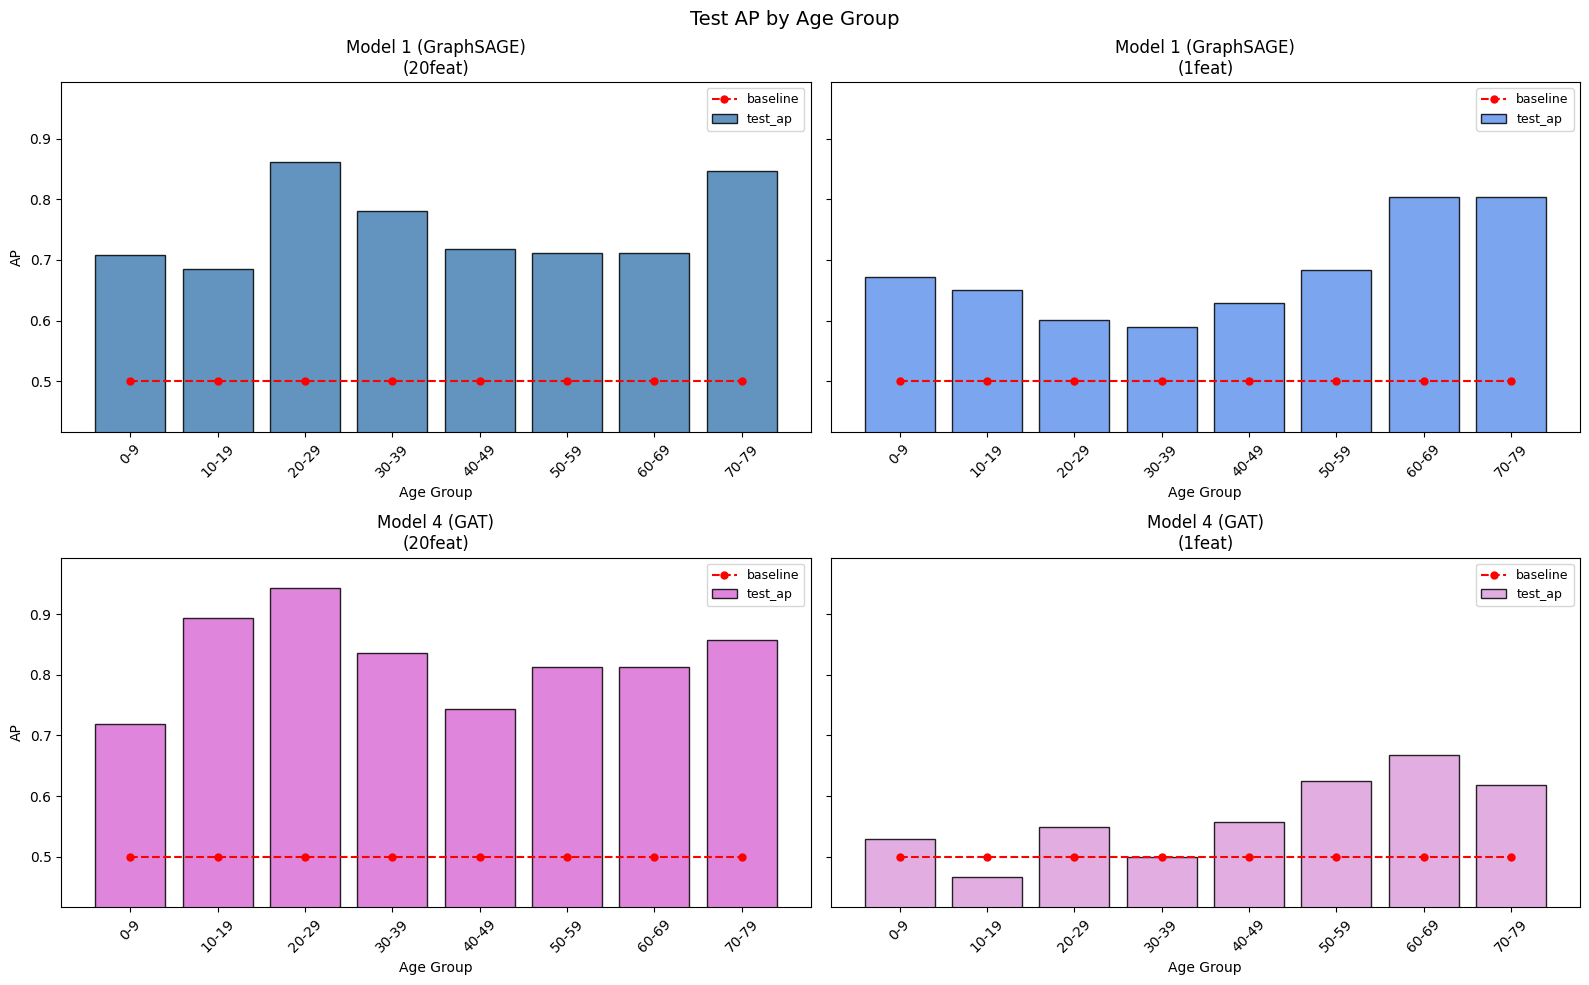

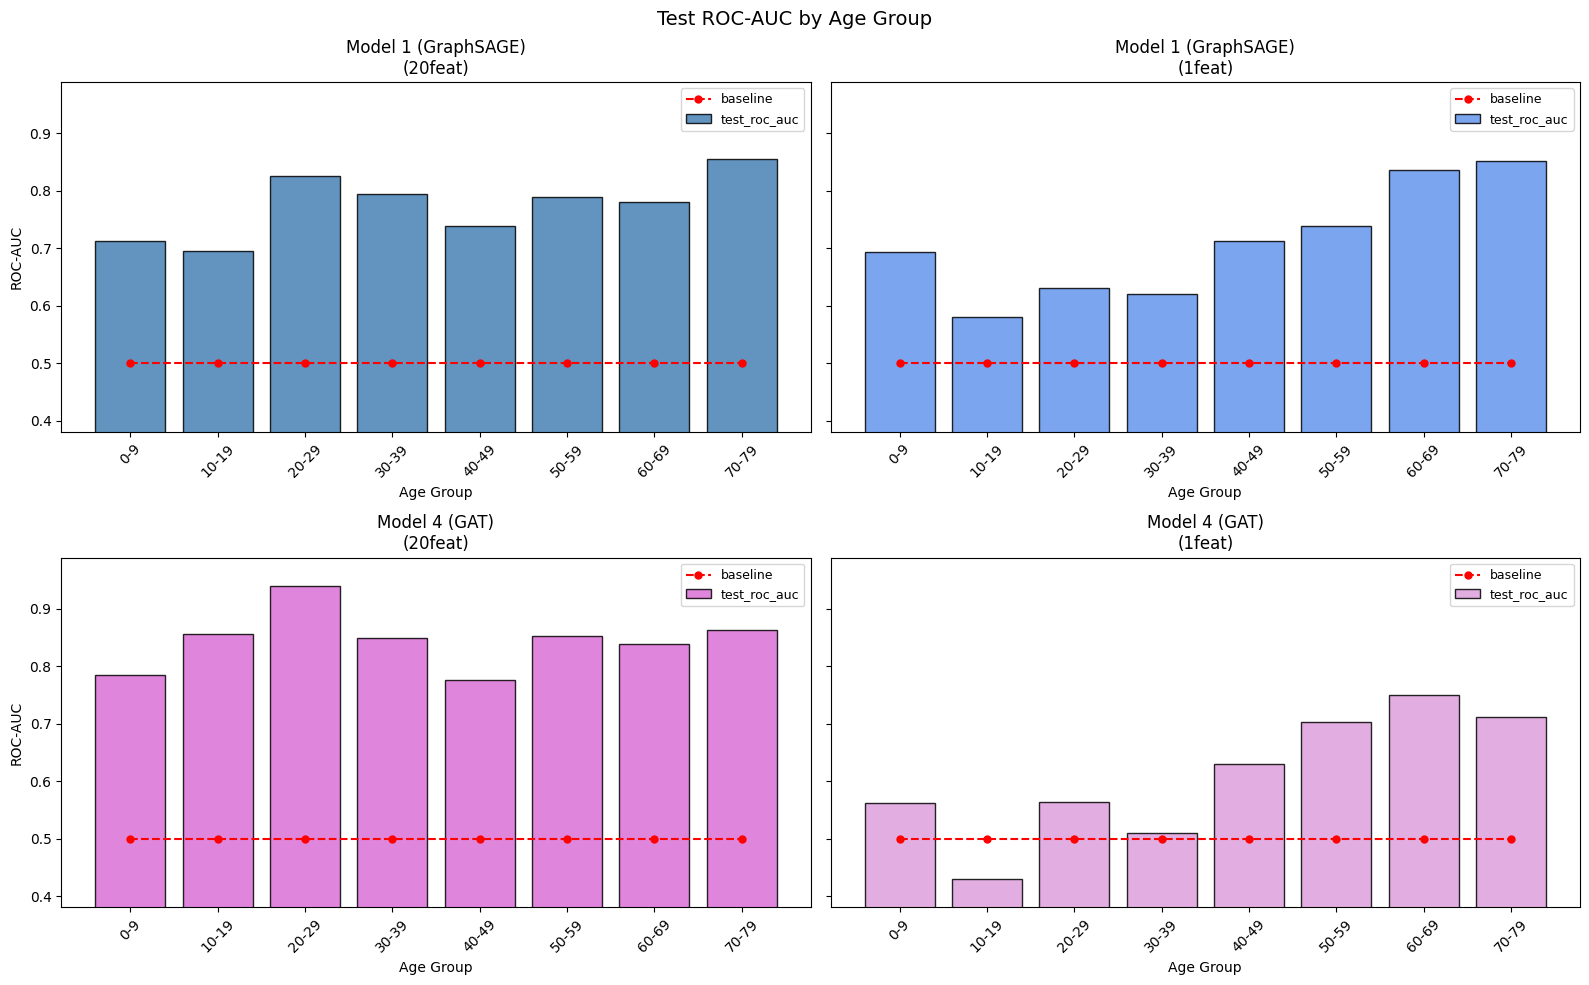

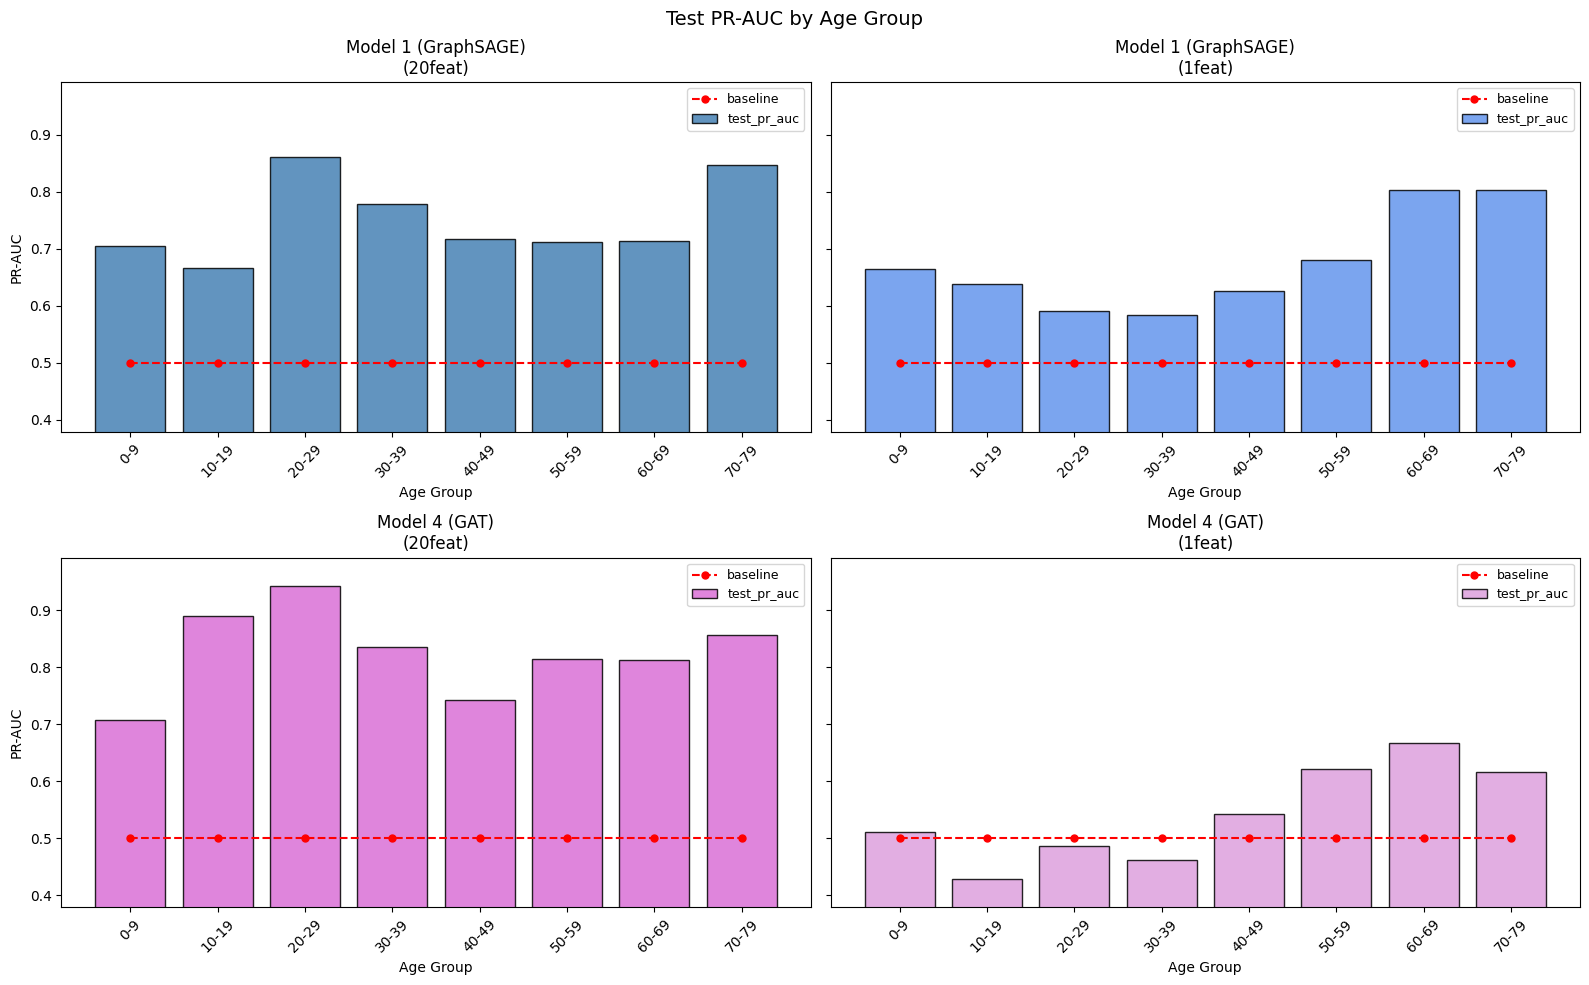

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plot_df = pd.concat(
    [results_m1_20, results_m1_1, results_m4_20, results_m4_1],
    ignore_index=True
)

age_labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79"]

panel_order = [
    ("Model 1 (GraphSAGE)", "20feat"),
    ("Model 1 (GraphSAGE)", "1feat"),
    ("Model 4 (GAT)", "20feat"),
    ("Model 4 (GAT)", "1feat"),
]

colors = ["steelblue", "cornflowerblue", "orchid", "plum"]


def plot_metric_panels(plot_df, metric, baseline_col, title, ylabel=None):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()

    vals_all = plot_df[metric].values
    base_all = plot_df[baseline_col].values

    ymin = max(0.0, min(vals_all.min(), base_all.min()) - 0.05)
    ymax = min(1.01, max(vals_all.max(), base_all.max()) + 0.05)

    for idx, (model_name, feature_name) in enumerate(panel_order):
        ax = axes[idx]

        df_sub = plot_df[
            (plot_df["model"] == model_name) &
            (plot_df["feature_set"] == feature_name)
        ].copy().sort_values("age_group")

        x = np.arange(len(df_sub))
        y = df_sub[metric].values
        baselines = df_sub[baseline_col].values

        ax.bar(x, y, color=colors[idx], edgecolor="black", alpha=0.85, label=metric)
        ax.plot(
            x, baselines,
            color="red",
            linestyle="--",
            marker="o",
            markersize=5,
            linewidth=1.5,
            label="baseline"
        )

        ax.set_title(f"{model_name}\n({feature_name})", fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(age_labels, rotation=45)
        ax.set_xlabel("Age Group")
        ax.set_ylim(ymin, ymax)

        if idx in [0, 2]:
            ax.set_ylabel(ylabel if ylabel is not None else metric)

        ax.legend(fontsize=9)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

#AP PLOT
plot_metric_panels(
    plot_df=plot_df,
    metric="test_ap",
    baseline_col="test_pr_baseline",
    title="Test AP by Age Group",
    ylabel="AP"
)

#PR-AUC ROC
plot_metric_panels(
    plot_df,
    metric="test_roc_auc",
    baseline_col="test_roc_baseline",
    title="Test ROC-AUC by Age Group",
    ylabel="ROC-AUC"
)

plot_metric_panels(
    plot_df,
    metric="test_pr_auc",
    baseline_col="test_pr_baseline",
    title="Test PR-AUC by Age Group",
    ylabel="PR-AUC"
)

In [11]:
results_df = pd.concat(
    [results_m1_20, results_m1_1, results_m4_20, results_m4_1],
    ignore_index=True
)

print(results_df)

print(
    results_df[
        ["model", "feature_set", "age_group", "test_pr_auc", "test_ap"]
    ].sort_values(["model", "feature_set", "age_group"]).round(4)
)

                  model feature_set  age_group  test_roc_auc   test_ap  \
0   Model 1 (GraphSAGE)      20feat          1      0.713026  0.708818   
1   Model 1 (GraphSAGE)      20feat          2      0.694444  0.684552   
2   Model 1 (GraphSAGE)      20feat          3      0.826087  0.861835   
3   Model 1 (GraphSAGE)      20feat          4      0.793345  0.780703   
4   Model 1 (GraphSAGE)      20feat          5      0.738261  0.718560   
5   Model 1 (GraphSAGE)      20feat          6      0.788494  0.711083   
6   Model 1 (GraphSAGE)      20feat          7      0.780041  0.711309   
7   Model 1 (GraphSAGE)      20feat          8      0.854081  0.847341   
8   Model 1 (GraphSAGE)       1feat          1      0.692618  0.671227   
9   Model 1 (GraphSAGE)       1feat          2      0.580247  0.651078   
10  Model 1 (GraphSAGE)       1feat          3      0.629962  0.601051   
11  Model 1 (GraphSAGE)       1feat          4      0.620360  0.589480   
12  Model 1 (GraphSAGE)       1feat   